# Create 2D composition space plots

For this tutorial, we need matplotlib and compspace obviously, as well as pandas and numpy for loading and manipulating the data.

In [1]:
import matplotlib.pyplot as plt
import compspace as cs
import pandas as pd
import numpy as np

Load the example data from a .csv with pandas. We also define a function to create subsets of the constituents. The dataset is a simulated materials library of an 8-component alloy system with 342 individual compositions.

In [2]:
# Load example data
comps = pd.read_csv('comp_example.csv', index_col=0)

# Function to create a subset of given constituents
def create_subset(c: pd.DataFrame, constituents: list[str]) -> pd.DataFrame:
    # Create the subset with the given constituents and re-normalize to 100 at.%
    subset = c[constituents]
    return subset.div(subset.sum(axis=1), axis=0) * 100

# Visualize the DataFrame
comps.head()

,Cr,Co,Cu,Fe,Mo,Mn,Ni,Ti
Index,,,,,,,,
1,15.28,4.13,18.34,33.47,6.52,4.84,10.10,7.32
2,15.53,5.10,18.63,33.31,8.60,3.75,8.73,6.35
3,14.24,5.64,17.09,32.04,9.55,6.15,8.91,6.37
4,12.70,6.56,15.24,32.01,11.33,6.75,9.41,6.01
5,12.65,6.22,15.18,33.19,11.24,6.79,8.15,6.59


We start by plotting a ternary subset of the data. The composition space plot can be created by passing ``compspace2D`` as a matplotlib projection when creating a new figure. The elements (columns in the DataFrame) are automatically added as axis labels.

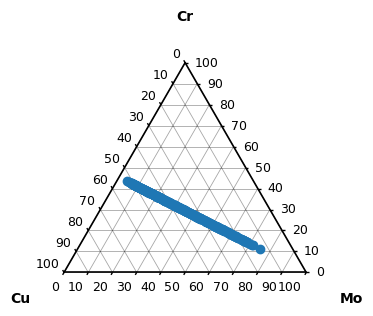

In [3]:
# Create a ternary subset
ternary_subset = create_subset(comps, ['Cr', 'Cu', 'Mo'])

# Create a figure with a ternary projection
fig, ax = plt.subplots(figsize=(4, 4), subplot_kw={'projection': 'compspace2D'})
# Scatter the data points
sc = ax.scatter(ternary_subset)
# Show the plot
plt.show()

For ternary and quaternary compositions, the grid and ticks are automatically added. This can be changed by ``ax.set_grid()`` and ``ax.set_ticks()`` respectively. For higher constistuents, these are disabled by default to avoid cluttering the plot, but are also available. Let's plot a quaternary subset and hide the grid and set different ticks.

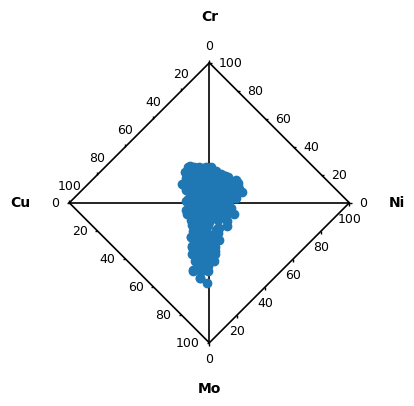

In [4]:
# Create a quaternary subset
quaternary_subset = create_subset(comps, ['Cr', 'Cu', 'Mo', 'Ni'])
# Only show ticks every 20 at. %
ticks = np.arange(0, 101, 20)

# Create a figure with a quaternary projection, the projection is still 'compspace2D'
fig, ax = plt.subplots(figsize=(4, 4), subplot_kw={'projection': 'compspace2D'})
# Scatter the data points
sc = ax.scatter(quaternary_subset)
# Hide the grid
ax.set_grid(False)
ax.set_ticks(ticks=ticks)
# Show the plot
plt.show()

Other parameters of ``ax.scatter`` are forwarded to the underlying matplotlib scatter function. For example, we can change the color and alpha of the markers. Below, this is shown for a quinary subset. Of course, also multiple composition sets can be plotted in the same composition space.

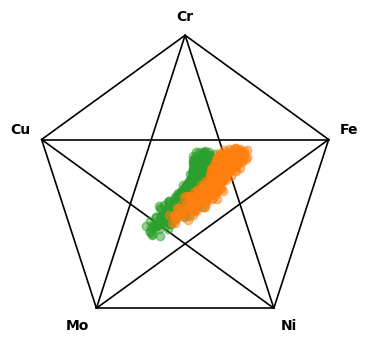

In [5]:
# Create a quinary subset
quinary_subset_1 = create_subset(comps, ['Cr', 'Cu', 'Mo', 'Ni', 'Fe'])
# Create a second quinary subset by doubling the Fe content
quinary_subset_2 = quinary_subset_1.copy()
quinary_subset_2['Fe'] = quinary_subset_2['Fe'] * 2
quinary_subset_2 = quinary_subset_2.div(quinary_subset_2.sum(axis=1), axis=0) * 100

# Create a figure with a quinary projection
fig, ax = plt.subplots(figsize=(4, 4), subplot_kw={'projection': 'compspace2D'})
# Specify the color and alpha of the markers
sc1 = ax.scatter(quinary_subset_1, c='tab:green', alpha=0.5)
sc2 = ax.scatter(quinary_subset_2, c='tab:orange', alpha=0.5)
# Show the plot
plt.show()

The ``c`` parameter also accepts an array of values instead of a single color, which colors the markers through a colormap. This is the way to show a property of each composition, for example a measured one. Here, the quaternary subset is colored by the Fe content of the full dataset, which is not part of the plotted composition space itself. The object returned by ``ax.scatter`` can be handed to ``fig.colorbar`` directly to add a colorbar.

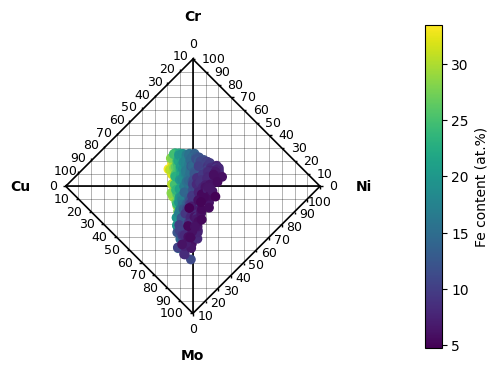

In [5]:
# Create a quaternary subset again
quaternary_subset = create_subset(comps, ['Cr', 'Cu', 'Mo', 'Ni'])

# Create a figure with a quaternary projection
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'projection': 'compspace2D'})
# Color the markers by the Fe content, any other property of the compositions works the same way
sc = ax.scatter(quaternary_subset, c=comps['Fe'], cmap='viridis')
# Add a colorbar and label it
cbar = fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.15)
cbar.set_label('Fe content (at.%)')
# Show the plot
plt.show()

The package supports plotting up to octonary (8-element) composition spaces. Let's plot the entire dataset with all 8 constituents.

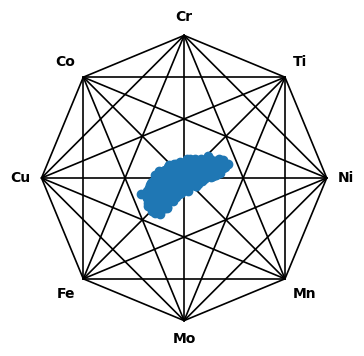

In [7]:
# Create a figure with an octonary projection
fig, ax = plt.subplots(figsize=(4, 4), subplot_kw={'projection': 'compspace2D'})
# Scatter the data points
sc = ax.scatter(comps)
# Show the plot
plt.show()

Instead of selecting a subset, constituents can also be grouped together. Passing a nested list to the ``labels`` parameter, e.g. ``['Cr', ['Cu', 'Ni']]``, sums up the grouped constituents and plots them as a single axis named ``Cu+Ni``. This reduces the number of dimensions to plot and works for ``ax.scatter``, ``ax.plot`` and the convenience function alike. Every constituent has to appear exactly once in the labels. Below, the 8 constituents are grouped into 3 to show the entire dataset in a ternary composition space.

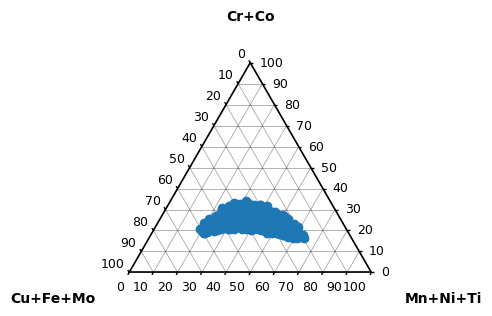

In [8]:
# Group the 8 constituents into 3 groups
groups = [['Cr', 'Co'], ['Cu', 'Fe', 'Mo'], ['Mn', 'Ni', 'Ti']]

# Create a figure with a ternary projection
fig, ax = plt.subplots(figsize=(4, 4), subplot_kw={'projection': 'compspace2D'})
# Scatter the data points, the grouped constituents are summed up internally
sc = ax.scatter(comps, labels=groups)
# Show the plot
plt.show()